# 02 — Preprocessing: Data Cleaning, Transformation & Feature Engineering

**TFM: Demand Forecasting for Inventory Management Using Machine Learning**

Author: Ona Mas i Serra

This notebook cleans the merged raw data from the EDA step, engineers lag/rolling/promotional features,
handles stock-break imputation and outlier capping, and produces the final `features.parquet` ready for modelling.


## Setup & Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, '/Users/omasiser/Library/CloudStorage/OneDrive-amazon.com/UOC/TFM forecasting/knowledge base/TFM_Ona_Code')
from style_config import apply_style, PRIMARY

%matplotlib inline

BASE_DIR = Path('/Users/omasiser/Library/CloudStorage/OneDrive-amazon.com/UOC/TFM forecasting/knowledge base/TFM_Ona_Code')
INPUT_PATH = BASE_DIR / 'output' / 'processed' / 'merged_raw.parquet'
OUTPUT_DIR = BASE_DIR / 'output' / 'processed'
PLOT_DIR = BASE_DIR / 'output' / 'preprocessing'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

apply_style()
plt.rcParams.update({'figure.figsize': (14, 6)})

def save_fig(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', bbox_inches='tight')
    plt.show()
    print(f'   → Saved {name}.png')


## 1. Load Merged Data

Load the merged raw parquet file produced by the EDA notebook.


In [2]:
print('=' * 60)
print('1. LOADING MERGED DATA')
print('=' * 60)

df = pd.read_parquet(INPUT_PATH)
print(f'Shape: {df.shape}')
print(f"Date range: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"Products: {df['producto'].nunique()}")


1. LOADING MERGED DATA


Shape: (629391, 13)
Date range: 2024-03-22 → 2026-03-22
Products: 861


## 2. Data Cleaning

Handle missing calendar values, missing stock, negative values, stock-break imputation,
and outlier treatment (3σ cap per product/month).


In [3]:
print('\n' + '=' * 60)
print('2. DATA CLEANING')
print('=' * 60)

n_before = len(df)

# 2.1 Handle missing calendario values
missing_cal = df['bolOpen'].isnull().sum()
print(f'Missing calendario rows: {missing_cal}')
df['bolOpen'] = df['bolOpen'].fillna(1).astype(int)
df['bolHoliday'] = df['bolHoliday'].fillna(0).astype(int)

# 2.2 Handle missing stock
missing_stock = df['udsStock'].isnull().sum()
print(f'Missing stock rows: {missing_stock}')
df = df.sort_values(['producto', 'fecha'])
df['udsStock'] = df.groupby('producto')['udsStock'].ffill().bfill()
remaining_null = df['udsStock'].isnull().sum()
print(f'Stock nulls after ffill/bfill: {remaining_null}')
if remaining_null > 0:
    df['udsStock'] = df['udsStock'].fillna(0)

# 2.3 Negative values
neg_sales = (df['udsVenta'] < 0).sum()
neg_stock = (df['udsStock'] < 0).sum()
print(f'Negative sales: {neg_sales} → clipped to 0')
print(f'Negative stock: {neg_stock} → clipped to 0')
df['udsVenta'] = df['udsVenta'].clip(lower=0)
df['udsStock'] = df['udsStock'].clip(lower=0)

# 2.4 Stock break imputation
stock_break_mask = (df['udsVenta'] == 0) & (df['udsStock'] == 0)
n_breaks = stock_break_mask.sum()
print(f'\nStock breaks before imputation: {n_breaks:,}')

df['_dow'] = df['fecha'].dt.dayofweek
df['_impute'] = df.groupby(['producto', '_dow'])['udsVenta'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean().shift(1)
)
product_dow_mean = df.groupby(['producto', '_dow'])['udsVenta'].transform('mean')
df['_impute'] = df['_impute'].fillna(product_dow_mean)

df.loc[stock_break_mask, 'udsVenta'] = df.loc[stock_break_mask, '_impute'].round().clip(lower=0)
df.drop(columns=['_dow', '_impute'], inplace=True)

n_breaks_after = ((df['udsVenta'] == 0) & (df['udsStock'] == 0)).sum()
print(f'Stock breaks after imputation: {n_breaks_after:,}')

# 2.5 Outlier treatment
print('\n── Outlier Treatment (3σ cap per product/month) ──')
df['_ym'] = df['fecha'].dt.to_period('M')
grp = df.groupby(['producto', '_ym'])['udsVenta']
upper = grp.transform('mean') + 3 * grp.transform('std')
outlier_mask = df['udsVenta'] > upper
n_outliers = outlier_mask.sum()
print(f'Outliers detected: {n_outliers:,} ({100*n_outliers/len(df):.2f}%)')
df.loc[outlier_mask, 'udsVenta'] = upper[outlier_mask].round()
df.drop(columns=['_ym'], inplace=True)

print(f'\nCleaning complete. Shape: {df.shape}')



2. DATA CLEANING
Missing calendario rows: 861
Missing stock rows: 861
Stock nulls after ffill/bfill: 0
Negative sales: 0 → clipped to 0
Negative stock: 0 → clipped to 0

Stock breaks before imputation: 12,572


Stock breaks after imputation: 10,425

── Outlier Treatment (3σ cap per product/month) ──
Outliers detected: 8,895 (1.41%)

Cleaning complete. Shape: (629391, 13)


## 3. Feature Engineering

Create calendar features, lag features (1, 7, 14, 28 days), rolling statistics,
EWMA, promotional features, and product-level static features.


In [4]:
print('\n' + '=' * 60)
print('3. FEATURE ENGINEERING')
print('=' * 60)

df = df.sort_values(['producto', 'fecha']).reset_index(drop=True)

# 3.1 Calendar features
print('3.1 Calendar features...')
df['week_of_month'] = (df['fecha'].dt.day - 1) // 7 + 1
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_month_start'] = (df['fecha'].dt.day <= 3).astype(int)
df['is_month_end'] = (df['fecha'].dt.day >= 28).astype(int)

# 3.2 Lag features
print('3.2 Lag features (1, 7, 14, 28 days)...')
for lag in [1, 7, 14, 28]:
    df[f'lag_{lag}'] = df.groupby('producto')['udsVenta'].shift(lag)

# 3.3 Rolling statistics
print('3.3 Rolling statistics (7d, 14d, 28d)...')
for window in [7, 14, 28]:
    rolled = df.groupby('producto')['udsVenta'].shift(1).groupby(df['producto'])
    df[f'roll_mean_{window}'] = rolled.transform(lambda x: x.rolling(window, min_periods=1).mean())
    df[f'roll_std_{window}'] = rolled.transform(lambda x: x.rolling(window, min_periods=1).std())
    df[f'roll_min_{window}'] = rolled.transform(lambda x: x.rolling(window, min_periods=1).min())
    df[f'roll_max_{window}'] = rolled.transform(lambda x: x.rolling(window, min_periods=1).max())

# 3.4 EWMA
print('3.4 EWMA (spans: 7, 28)...')
shifted = df.groupby('producto')['udsVenta'].shift(1)
for span in [7, 28]:
    df[f'ewma_{span}'] = shifted.groupby(df['producto']).transform(
        lambda x: x.ewm(span=span, min_periods=1).mean()
    )



3. FEATURE ENGINEERING
3.1 Calendar features...
3.2 Lag features (1, 7, 14, 28 days)...
3.3 Rolling statistics (7d, 14d, 28d)...


3.4 EWMA (spans: 7, 28)...


### 3.5 Promotional & Product-Level Features

Compute days since last promo ended, post-promo lag effects, promo×lag interaction,
and per-product static aggregates (mean, std, median sales).


In [5]:
# 3.5 Promotional features
print('3.5 Promotional features...')
df['_promo_change'] = df.groupby('producto')['en_promo'].diff().fillna(0)
df['_promo_end'] = (df['_promo_change'] == -1).astype(int)

def days_since_event(series):
    result = pd.Series(np.nan, index=series.index)
    last_event = np.nan
    for i, val in enumerate(series):
        if val == 1:
            last_event = 0
        elif not np.isnan(last_event):
            last_event += 1
        result.iloc[i] = last_event
    return result

df['days_since_promo_end'] = df.groupby('producto')['_promo_end'].transform(days_since_event)
df['days_since_promo_end'] = df['days_since_promo_end'].fillna(-1)

df['post_promo_7d'] = ((df['days_since_promo_end'] >= 0) & (df['days_since_promo_end'] <= 7)).astype(int)
df['promo_x_lag7'] = df['en_promo'] * df['lag_7'].fillna(0)
df.drop(columns=['_promo_change', '_promo_end'], inplace=True)

# 3.6 Product-level static features
print('3.6 Product-level features...')
prod_agg = df.groupby('producto')['udsVenta'].agg(
    prod_mean_sales='mean',
    prod_std_sales='std',
    prod_median_sales='median'
).reset_index()
df = df.merge(prod_agg, on='producto', how='left')


3.5 Promotional features...


3.6 Product-level features...


## 4. Handle NaNs from Feature Engineering

Drop the first 28 days per product (warmup period for lag_28) and fill any remaining NaNs.


In [6]:
print('\n' + '=' * 60)
print('4. HANDLING NaNs FROM FEATURE ENGINEERING')
print('=' * 60)

warmup_days = 28
df['_day_rank'] = df.groupby('producto')['fecha'].rank(method='dense').astype(int)
n_before_warmup = len(df)
df = df[df['_day_rank'] > warmup_days].copy()
df.drop(columns=['_day_rank'], inplace=True)
n_after_warmup = len(df)

print(f'Rows before warmup removal: {n_before_warmup:,}')
print(f'Rows after warmup removal:  {n_after_warmup:,}')
print(f'Removed: {n_before_warmup - n_after_warmup:,} ({100*(n_before_warmup-n_after_warmup)/n_before_warmup:.1f}%)')

remaining_nans = df.isnull().sum()
has_nans = remaining_nans[remaining_nans > 0]
if len(has_nans) > 0:
    print(f'\nRemaining NaNs:\n{has_nans}')
    df = df.fillna(0)
else:
    print('No remaining NaNs.')



4. HANDLING NaNs FROM FEATURE ENGINEERING


Rows before warmup removal: 629,391
Rows after warmup removal:  605,283
Removed: 24,108 (3.8%)
No remaining NaNs.


## 5. Feature Summary & Visualisation

Summarise the engineered features and plot their correlation with the target variable (udsVenta).



5. FEATURE SUMMARY
Total features: 37
Feature list: ['udsVenta', 'udsStock', 'bolOpen', 'bolHoliday', 'en_promo', 'year', 'month', 'day_of_week', 'week_of_year', 'week_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_min_7', 'roll_max_7', 'roll_mean_14', 'roll_std_14', 'roll_min_14', 'roll_max_14', 'roll_mean_28', 'roll_std_28', 'roll_min_28', 'roll_max_28', 'ewma_7', 'ewma_28', 'days_since_promo_end', 'post_promo_7d', 'promo_x_lag7', 'prod_mean_sales', 'prod_std_sales', 'prod_median_sales']

Final shape: (605283, 41)
Date range: 2024-04-19 → 2026-03-22
Products: 861



── Top 15 features correlated with udsVenta ──
ewma_28              0.451284
roll_mean_28         0.450445
roll_mean_14         0.439779
prod_mean_sales      0.429997
roll_mean_7          0.415987
ewma_7               0.401016
prod_median_sales    0.373670
prod_std_sales       0.367988
roll_std_28          0.362144
roll_std_14          0.351371
roll_max_7           0.339572
roll_std_7           0.331152
roll_max_14          0.330453
lag_7                0.326911
lag_14               0.313951
Name: udsVenta, dtype: float64

── Bottom 5 ──
year             -0.000247
is_month_start   -0.005666
is_weekend       -0.124887
day_of_week      -0.141457
bolHoliday       -0.156951
Name: udsVenta, dtype: float64


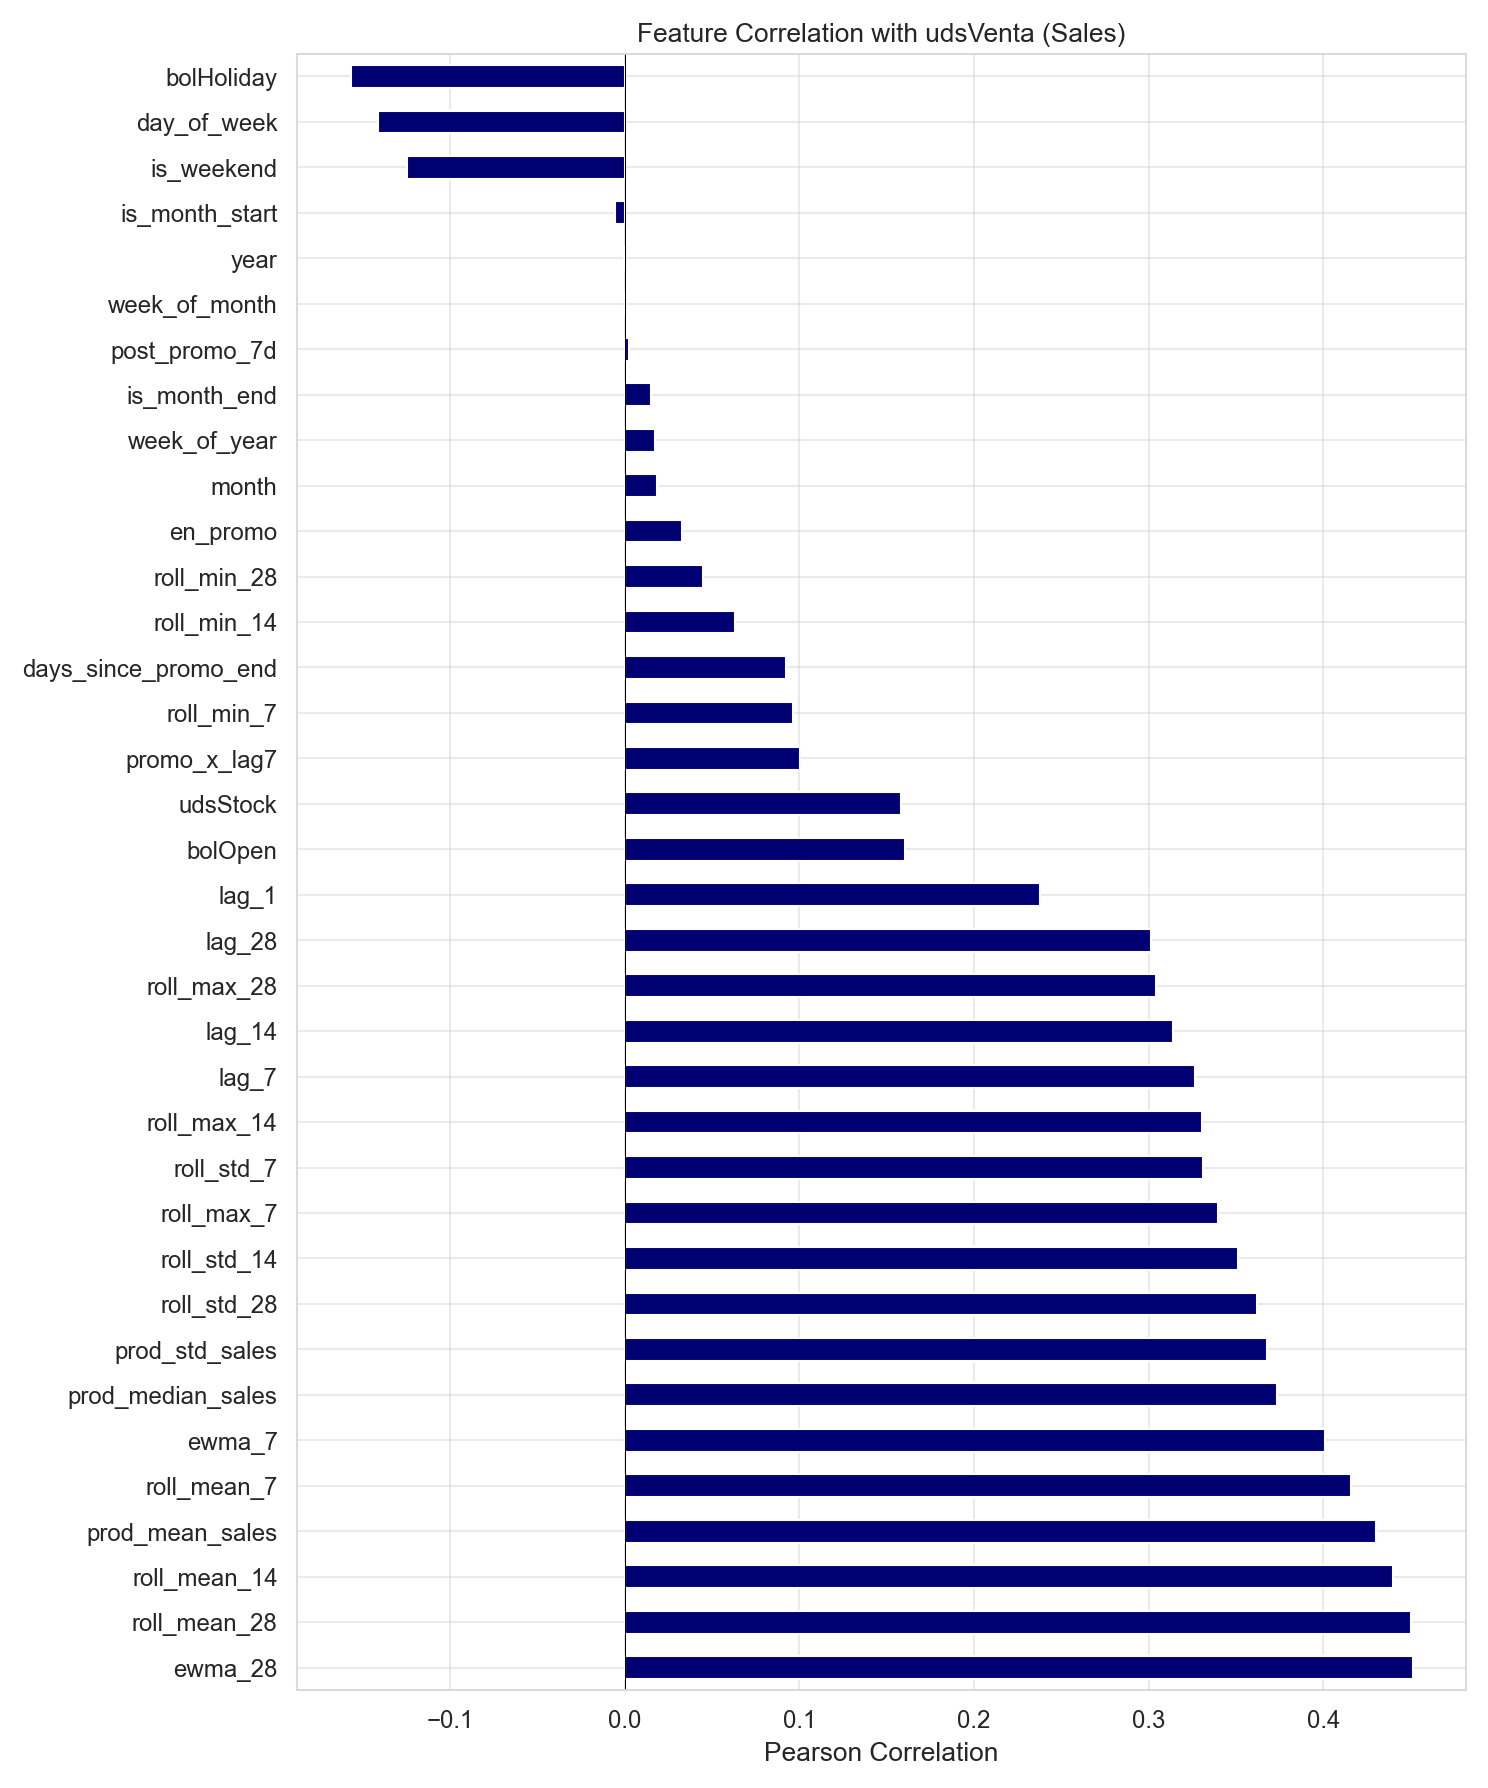

   → Saved 10_feature_correlations.png


In [7]:
print('\n' + '=' * 60)
print('5. FEATURE SUMMARY')
print('=' * 60)

feature_cols = [c for c in df.columns if c not in ['producto', 'idSecuencia', 'fecha', 'day_name']]
print(f'Total features: {len(feature_cols)}')
print(f'Feature list: {feature_cols}')
print(f'\nFinal shape: {df.shape}')
print(f"Date range: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"Products: {df['producto'].nunique()}")

corr_with_target = df[feature_cols].corr()['udsVenta'].drop('udsVenta').sort_values(ascending=False)
print(f'\n── Top 15 features correlated with udsVenta ──')
print(corr_with_target.head(15))
print(f'\n── Bottom 5 ──')
print(corr_with_target.tail(5))

fig, ax = plt.subplots(figsize=(10, 12))
corr_with_target.plot(kind='barh', ax=ax, color=PRIMARY)
ax.set_title('Feature Correlation with udsVenta (Sales)')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
save_fig('10_feature_correlations')


## 6. Save Processed Data

Export the final feature-engineered dataset to parquet and save the feature name list.


In [8]:
print('\n' + '=' * 60)
print('6. SAVING PROCESSED DATA')
print('=' * 60)

df.to_parquet(OUTPUT_DIR / 'features.parquet', index=False)
print(f"✓ Saved features.parquet ({df.shape[0]:,} rows × {df.shape[1]} cols)")

feature_names = [c for c in feature_cols if c != 'udsVenta']
pd.Series(feature_names).to_csv(OUTPUT_DIR / 'feature_names.csv', index=False, header=False)
print(f'✓ Saved feature_names.csv ({len(feature_names)} features)')

print('\n' + '=' * 60)
print('PREPROCESSING COMPLETE')
print('=' * 60)



6. SAVING PROCESSED DATA


✓ Saved features.parquet (605,283 rows × 41 cols)
✓ Saved feature_names.csv (36 features)

PREPROCESSING COMPLETE
